# 🐍 Exemplo de rede neural

Exemplo prático do capítulo: 2.6 Erro e função de perda

In [46]:
#@title 1 - Importamos as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import f1_score
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [4]:
#@title 2 - Conectar com o Google Drive para obter os DataSets

from google.colab import drive

# Montar o Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
#@title 3 - carregamos os dados necessários
path = "/content/drive/MyDrive/Livro_LLM/Codigo_Livro_LLM/Capitulo2/Codigo_Capitulo_2_6"
df_train = pd.read_csv(f"{path}/binary_test.csv")
df_test = pd.read_csv(f"{path}/binary_train.csv")

In [43]:
#@title 4 - Visualização dos dados
df_train.head()

,source,text,researcher,year,aggressive,hate
0,twitter,RT @user Geraldo Alckmin vs Jair Bolsonaro\nA ...,fortuna et al,2019,0,0
1,twitter,@user @user vacila não buceta (mas eu faço o m...,leite et al,2020,1,0
2,twitter,@user todo dia um jovem passando vergonha na i...,leite et al,2020,0,0
3,twitter,eu com o chip da claro 馃憥馃従,leite et al,2020,0,0
4,instagram,Todo o lixo veio a tona!,vargas et al,2021,0,0


In [14]:
#@title 5 - Total encontrado de agressividade por rede social
agressivos = df_train[df_train['aggressive'] == 1]
agressivos_por_source = agressivos['source'].value_counts()

agressivos_por_source

,count
source,
twitter,1561
instagram,726


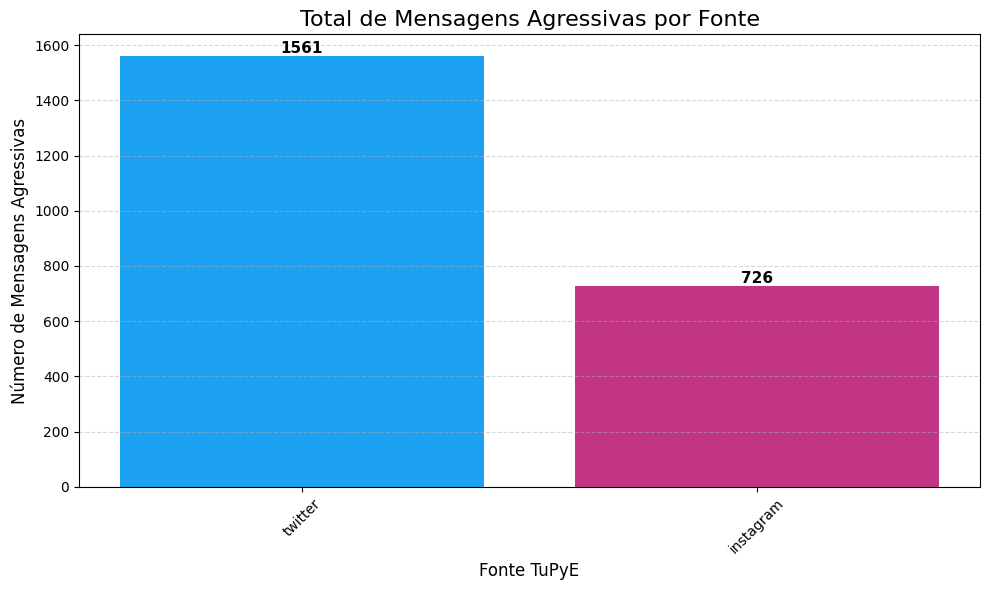

In [21]:
#@title 6 - Exibir o total encontrado em gráfico
cores_personalizadas = {
    'twitter': '#1DA1F2',
    'instagram': '#C13584'
}

cores = [cores_personalizadas.get(fonte, '#888888') for fonte in agressivos_por_source.index]

plt.figure(figsize=(10, 6))
bars = plt.bar(agressivos_por_source.index, agressivos_por_source.values, color=cores)

plt.title('Total de Mensagens Agressivas por Fonte', fontsize=16)
plt.xlabel('Fonte TuPyE', fontsize=12)
plt.ylabel('Número de Mensagens Agressivas', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [25]:
#@title 7 - Iniciamos o treinamento da nossa rede

# Parâmetros
max_words = 10000
max_len = 100

# Tokenizador
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df_train["text"])

# Transforma texto em sequência de inteiros
X_train_seq = tokenizer.texts_to_sequences(df_train["text"])
X_test_seq = tokenizer.texts_to_sequences(df_test["text"])

# Padding (ajuste de tamanho)
X_train = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

In [27]:
df_train

,source,text,researcher,year,aggressive,hate
0,twitter,RT @user Geraldo Alckmin vs Jair Bolsonaro\nA ...,fortuna et al,2019,0,0
1,twitter,@user @user vacila não buceta (mas eu faço o m...,leite et al,2020,1,0
2,twitter,@user todo dia um jovem passando vergonha na i...,leite et al,2020,0,0
3,twitter,eu com o chip da claro 馃憥馃従,leite et al,2020,0,0
4,instagram,Todo o lixo veio a tona!,vargas et al,2021,0,0
...,...,...,...,...,...,...
8729,instagram,Enfermo culiao hijo de la maraca sopla moco te...,vargas et al,2021,1,0
8730,twitter,ai sinceramente se eu tiver nos meus 30 e pouc...,oliveira et al,2023,0,0
8731,twitter,"@user sim mano, fora a demora.\nsão 6 testes q...",leite et al,2020,0,0
8732,instagram,#foracomunismosocialismo🤬😠😡👊👊👊,vargas et al,2021,1,1


In [32]:
#@title 8 - Total que obtivemos de agressividade do DataSet
y_train = df_train["aggressive"].values
y_test = df_test["aggressive"].values

df_train["aggressive"].value_counts()

,count
aggressive,
0,6447
1,2287


In [34]:
#@title 9 - Treinamento da nossa rede neural

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=max_words, output_dim=32),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

model.summary()

history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
#@title 9 - Avaliamos a acurácia da nossa rede neural ou seja o quanto ela acerta.

loss, acc = model.evaluate(X_test, y_test)
print(f"Acurácia: {acc:.4f}")

1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7896 - loss: 0.4725
Acurácia: 0.7899


In [37]:
#@title 10 - Criação da nossa função de validação do input do usuário
def prever_texto(texto):
    seq = tokenizer.texts_to_sequences([texto])
    pad = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")
    pred = model.predict(pad)[0][0]
    return pred

In [39]:
#@title 11 - Obter o texto do usuário

texto_do_usuario = input("Digite um texto: ")

f"Você digitou: {texto_do_usuario}"

Digite um texto: Olá tudo bem?


'Você digitou: Olá tudo bem?'

In [40]:
#@title 12 - Validação da frase
score = prever_texto(texto_do_usuario)
if score >= 0.5:
    print("⚠️ Frase provavelmente tóxica!")
else:
    print("✅ Frase provavelmente limpa.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
✅ Frase provavelmente limpa.
